In [1]:
import pandas as pd
import kagglehub

lacuna_path = kagglehub.dataset_download("rajsahu2004/lacuna-malaria-detection-dataset")

train_df = pd.read_csv(f"{lacuna_path}/Train.csv")
test_df  = pd.read_csv(f"{lacuna_path}/Test.csv")

print("Train CSV shape:", train_df.shape)
print("\nTrain CSV columns:", train_df.columns.tolist())
print("\nFirst 5 rows:")
print(train_df.head())
print("\nUnique label values:")
print(train_df.iloc[:, -1].value_counts())

Train CSV shape: (23530, 7)

Train CSV columns: ['Image_ID', 'class', 'confidence', 'ymin', 'xmin', 'ymax', 'xmax']

First 5 rows:
            Image_ID        class  confidence  ymin  xmin  ymax  xmax
0  id_u3q6jdck4j.jpg  Trophozoite         1.0   712  1241   737  1270
1  id_a6cl90trri.jpg  Trophozoite         1.0   558  1566   600  1604
2  id_qvc2le9sm8.jpg  Trophozoite         1.0  1317  2788  1448  2914
3  id_w8xnbd5rvm.jpg  Trophozoite         1.0   925  1744  1041  1823
4  id_6dop09rk02.jpg          NEG         1.0     0     0     0     0

Unique label values:
xmax
0       688
893      37
919      37
995      36
1258     35
       ... 
3743      1
2582      1
2298      1
3898      1
2507      1
Name: count, Length: 3139, dtype: int64


In [2]:
print("Class column values:")
print(train_df['class'].value_counts())

print("\nUnique images:", train_df['Image_ID'].nunique())

# How many images are purely NEG vs have parasites
neg_images = train_df.groupby('Image_ID')['class'].apply(
    lambda x: (x == 'NEG').all()
)
print(f"\nNegative images (all NEG): {neg_images.sum()}")
print(f"Positive images (has parasite): {(~neg_images).sum()}")

Class column values:
class
Trophozoite    15838
WBC             7004
NEG              688
Name: count, dtype: int64

Unique images: 2747

Negative images (all NEG): 688
Positive images (has parasite): 2059


In [3]:
import os

# Find where images actually live
img_folder = f"{lacuna_path}/images"
sample_images = os.listdir(img_folder)[:5]
print("Sample image filenames:", sample_images)
print("Total files in images/:", len(os.listdir(img_folder)))

# Check if Train.csv Image_IDs match filenames directly
print("\nFirst Image_ID from CSV:", train_df['Image_ID'].iloc[0])
print("Does it exist in folder?", 
      train_df['Image_ID'].iloc[0] in os.listdir(img_folder))

# Check image sizes - are these whole FOV images?
from PIL import Image
sample_img = Image.open(f"{img_folder}/{sample_images[0]}")
print("\nSample image size:", sample_img.size)

Sample image filenames: ['id_mereo6283h.jpg', 'id_b3dellefqq.jpg', 'id_ttaf35684u.jpg', 'id_sbil497x0b.jpg', 'id_o5t15za89r.jpg']
Total files in images/: 3925

First Image_ID from CSV: id_u3q6jdck4j.jpg
Does it exist in folder? True

Sample image size: (4160, 3120)


Using device: cuda
Stage 1 model found at: /kaggle/input/datasets/gwaceee/miccai-dataset/source_domain_model_final.pth

Loading NIH probe set (source domain):
NIH probe set: 500 images (~250 pos, ~250 neg)

Loading Lacuna probe set (target domain):
Lacuna probe set: 500 images (250 pos, 250 neg)
  Note: images are full FOV 4160x3120 → resized to 224x224

Loading source domain model from Stage 1...
Model loaded successfully.

Extracting features from NIH probe set (source domain):
    Processed 160 images...
    Processed 320 images...
    Processed 480 images...
  Layer  0: feature matrix shape (500, 768)
  Layer  1: feature matrix shape (500, 768)
  Layer  2: feature matrix shape (500, 768)
  Layer  3: feature matrix shape (500, 768)
  Layer  4: feature matrix shape (500, 768)
  Layer  5: feature matrix shape (500, 768)
  Layer  6: feature matrix shape (500, 768)
  Layer  7: feature matrix shape (500, 768)
  Layer  8: feature matrix shape (500, 768)
  Layer  9: feature matrix shape (5

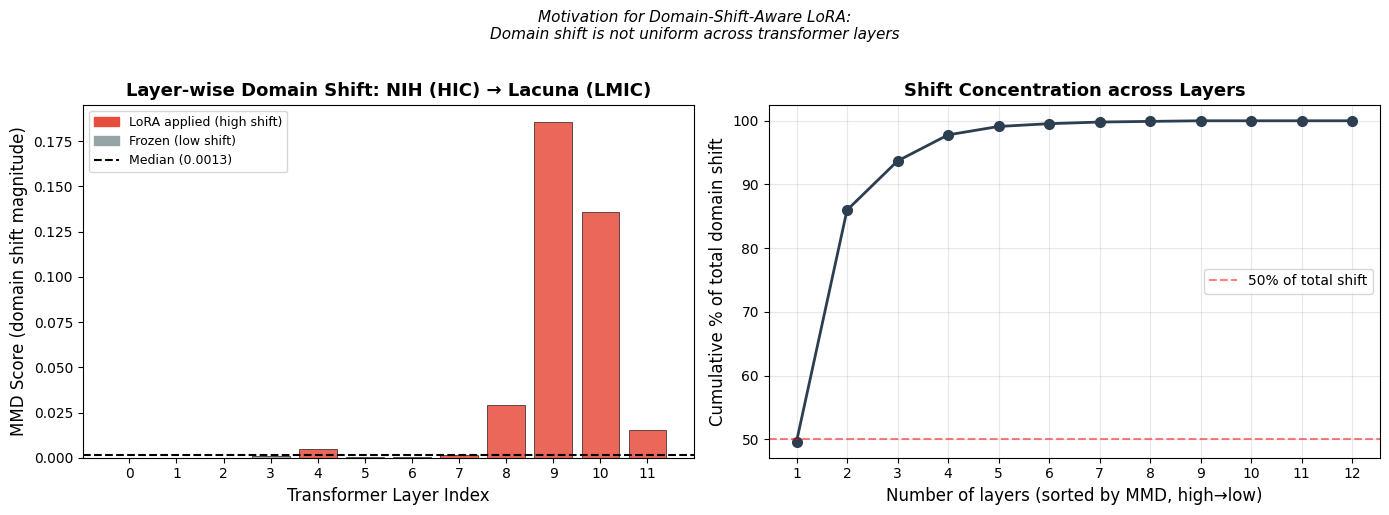

Figure 1 saved to: /kaggle/working/stage2_mmd_figure1.png

STAGE 2 COMPLETE — Summary

Domain shift analysis: NIH (HIC) → Lacuna (LMIC)
Probe set size: 500 images per domain

Per-layer MMD scores:
 Layer    MMD Score     Decision
--------------------------------
     0     0.000000       Frozen
     1     0.000000       Frozen
     2     0.000000       Frozen
     3     0.000965       Frozen
     4     0.004944         LoRA ←
     5     0.000353       Frozen
     6     0.000393       Frozen
     7     0.001637         LoRA ←
     8     0.028889         LoRA ←
     9     0.185914         LoRA ←
    10     0.136138         LoRA ←
    11     0.015342         LoRA ←

Conclusion:
  6 layers show high domain shift → LoRA applied
  6 layers show low domain shift  → Frozen

This layer selection is saved to: stage2_mmd_results.json
Load it in Stage 3 to configure your domain-shift-aware LoRA.

Next step: Stage 3 — Comparative fine-tuning experiments


In [4]:
# =============================================================================
# STAGE 2: Layer-wise MMD Computation
# Domain-Shift-Aware LoRA for Malaria Detection in LMIC Settings
#
# What this notebook does:
#   - Loads the source domain model trained in Stage 1
#   - Loads a probe set from both NIH (source) and Lacuna (target) datasets
#   - Registers forward hooks on each ViT transformer block
#   - Extracts CLS token features at each layer for both domains
#   - Computes Maximum Mean Discrepancy (MMD) per layer
#   - Plots the per-layer domain shift — this becomes Figure 1 of your paper
#   - Saves the layer selection decision for Stage 3
#
# Estimated runtime: ~15-20 minutes on Kaggle T4
# =============================================================================


# ── 0. IMPORTS ────────────────────────────────────────────────────────────────

import os
import random
import numpy as np
import pandas as pd
from pathlib import Path
from PIL import Image

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
import timm

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# ── 1. REPRODUCIBILITY + GPU CHECK ───────────────────────────────────────────

SEED = 42
random.seed(SEED); np.random.seed(SEED)
torch.manual_seed(SEED); torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {DEVICE}")

if str(DEVICE) == "cpu":
    raise RuntimeError(
        "No GPU detected. "
        "Go to Kaggle → Session options → Accelerator → GPU T4 x2"
    )

# ── 2. PATHS ──────────────────────────────────────────────────────────────────

import kagglehub

nih_path    = kagglehub.dataset_download("shahriar26s/malaria-detection")
lacuna_path = kagglehub.dataset_download("rajsahu2004/lacuna-malaria-detection-dataset")

# Stage 1 model — adjust this path to match your uploaded dataset name
# It will be something like /kaggle/input/miccai-dataset/
STAGE1_MODEL_PATH = None
for root, dirs, files in os.walk('/kaggle/input'):
    for f in files:
        if f == 'source_domain_model_final.pth':
            STAGE1_MODEL_PATH = os.path.join(root, f)
            break

if STAGE1_MODEL_PATH is None:
    raise FileNotFoundError(
        "Could not find source_domain_model_final.pth in /kaggle/input. "
        "Make sure you added your Stage 1 model dataset as an input."
    )

print(f"Stage 1 model found at: {STAGE1_MODEL_PATH}")

OUTPUT_DIR = '/kaggle/working/'

# ── 3. DATASET CLASSES ────────────────────────────────────────────────────────

class NIHProbeDataset(Dataset):
    """
    Loads a random probe subset from the NIH dataset (source domain).
    Used only for feature extraction — no training.
    """
    def __init__(self, root_dir, transform=None, n_samples=500, seed=42):
        self.transform = transform
        self.samples   = []
        root_dir       = Path(root_dir)
        valid_ext      = {'.jpg', '.jpeg', '.png'}

        for folder in root_dir.iterdir():
            if not folder.is_dir():
                continue
            name = folder.name.lower()
            label = 1 if 'parasit' in name else 0 if 'uninfect' in name else None
            if label is None:
                continue
            for img_path in folder.iterdir():
                if img_path.suffix.lower() in valid_ext:
                    self.samples.append((str(img_path), label))

        # Sample a balanced probe set
        random.seed(seed)
        pos = [s for s in self.samples if s[1] == 1]
        neg = [s for s in self.samples if s[1] == 0]
        n_each = n_samples // 2
        self.samples = random.sample(pos, min(n_each, len(pos))) + \
                       random.sample(neg, min(n_each, len(neg)))
        random.shuffle(self.samples)

        print(f"NIH probe set: {len(self.samples)} images "
              f"(~{sum(1 for s in self.samples if s[1]==1)} pos, "
              f"~{sum(1 for s in self.samples if s[1]==0)} neg)")

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        img_path, label = self.samples[idx]
        image = Image.open(img_path).convert('RGB')
        if self.transform:
            image = self.transform(image)
        return image, label


class LacunaProbeDataset(Dataset):
    """
    Loads a random probe subset from the Lacuna dataset (target domain).
    Converts bounding-box CSV to image-level binary labels:
        - Any image with a Trophozoite annotation → Parasitized (1)
        - Images with only NEG or WBC → Uninfected (0)

    Note: Images are full field-of-view (4160x3120) smartphone captures.
    They are resized to 224x224 — this intentional resolution compression
    is part of the domain shift we are measuring.
    """
    def __init__(self, csv_path, img_dir, transform=None,
                 n_samples=500, seed=42):
        self.transform = transform
        self.img_dir   = Path(img_dir)

        df = pd.read_csv(csv_path)

        # Image-level label: 1 if any Trophozoite in that image
        image_labels = df.groupby('Image_ID')['class'].apply(
            lambda x: 1 if (x == 'Trophozoite').any() else 0
        ).reset_index()
        image_labels.columns = ['Image_ID', 'label']

        # Keep only images that actually exist in the folder
        existing = set(os.listdir(self.img_dir))
        image_labels = image_labels[image_labels['Image_ID'].isin(existing)]

        # Sample a balanced probe set
        random.seed(seed)
        pos = image_labels[image_labels['label'] == 1]['Image_ID'].tolist()
        neg = image_labels[image_labels['label'] == 0]['Image_ID'].tolist()
        n_each = n_samples // 2
        # Note: only 688 negatives available — may be fewer than n_each
        sampled_pos = random.sample(pos, min(n_each, len(pos)))
        sampled_neg = random.sample(neg, min(n_each, len(neg)))

        self.samples = (
            [(img_id, 1) for img_id in sampled_pos] +
            [(img_id, 0) for img_id in sampled_neg]
        )
        random.shuffle(self.samples)

        print(f"Lacuna probe set: {len(self.samples)} images "
              f"({len(sampled_pos)} pos, {len(sampled_neg)} neg)")
        print(f"  Note: images are full FOV {4160}x{3120} → resized to 224x224")

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        img_id, label = self.samples[idx]
        img_path = self.img_dir / img_id
        image = Image.open(img_path).convert('RGB')
        if self.transform:
            image = self.transform(image)
        return image, label


# ── 4. TRANSFORMS ─────────────────────────────────────────────────────────────

# Same normalisation as Stage 1 — no augmentation for feature extraction
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

probe_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

# ── 5. LOAD PROBE DATASETS ────────────────────────────────────────────────────

# Find NIH train dir
def find_split_dir(base_path, split_name):
    for p in Path(base_path).rglob('*'):
        if p.is_dir() and p.name.lower() == split_name.lower():
            subdirs = [d for d in p.iterdir() if d.is_dir()]
            if len(subdirs) >= 2:
                return p
    return None

nih_train_dir = find_split_dir(nih_path, 'train')

N_PROBE = 500  # 500 images per domain for MMD computation

print("\nLoading NIH probe set (source domain):")
nih_probe = NIHProbeDataset(nih_train_dir, transform=probe_transform,
                            n_samples=N_PROBE)

print("\nLoading Lacuna probe set (target domain):")
lacuna_probe = LacunaProbeDataset(
    csv_path=f"{lacuna_path}/Train.csv",
    img_dir=f"{lacuna_path}/images",
    transform=probe_transform,
    n_samples=N_PROBE
)

nih_loader    = DataLoader(nih_probe,    batch_size=32, shuffle=False,
                           num_workers=2, pin_memory=True)
lacuna_loader = DataLoader(lacuna_probe, batch_size=32, shuffle=False,
                           num_workers=2, pin_memory=True)


# ── 6. LOAD SOURCE MODEL ──────────────────────────────────────────────────────

print(f"\nLoading source domain model from Stage 1...")
model = timm.create_model('vit_base_patch16_224', pretrained=False, num_classes=2)
checkpoint = torch.load(STAGE1_MODEL_PATH, map_location=DEVICE, weights_only=False)
model.load_state_dict(checkpoint['model_state'])
model = model.to(DEVICE)
model.eval()
print("Model loaded successfully.")

# ── 7. HOOK-BASED FEATURE EXTRACTION ─────────────────────────────────────────
#
# ViT-B/16 has 12 transformer blocks (blocks[0] to blocks[11]).
# We register a forward hook on each block to capture the CLS token output.
# The CLS token (index 0) is the global representation of the image at that layer.
# Shape after each block: [batch_size, num_patches+1, hidden_dim]
# We take index 0 → [batch_size, hidden_dim] = [batch_size, 768]

def extract_layer_features(model, loader, device, n_layers=12):
    """
    Extract CLS token features from all 12 ViT blocks for a given dataset.

    Returns:
        features: dict {layer_idx: np.array of shape [N, 768]}
    """
    features = {i: [] for i in range(n_layers)}
    hooks    = []

    # Register hooks on each transformer block
    def make_hook(layer_idx):
        def hook(module, input, output):
            # output shape: [batch, seq_len, hidden_dim]
            # CLS token is at position 0
            cls_token = output[:, 0, :].detach().cpu()
            features[layer_idx].append(cls_token)
        return hook

    for i in range(n_layers):
        h = model.blocks[i].register_forward_hook(make_hook(i))
        hooks.append(h)

    # Forward pass through all batches
    with torch.no_grad():
        for batch_idx, (images, _) in enumerate(loader):
            images = images.to(device)
            _ = model(images)
            if (batch_idx + 1) % 5 == 0:
                print(f"    Processed {(batch_idx+1)*loader.batch_size} images...")

    # Remove hooks
    for h in hooks:
        h.remove()

    # Concatenate batches
    for i in range(n_layers):
        features[i] = torch.cat(features[i], dim=0).numpy()
        print(f"  Layer {i:2d}: feature matrix shape {features[i].shape}")

    return features


print("\nExtracting features from NIH probe set (source domain):")
nih_features = extract_layer_features(model, nih_loader, DEVICE)

print("\nExtracting features from Lacuna probe set (target domain):")
lacuna_features = extract_layer_features(model, lacuna_loader, DEVICE)


# ── 8. MMD COMPUTATION ───────────────────────────────────────────────────────
#
# Maximum Mean Discrepancy (MMD) measures the distance between two
# probability distributions in a reproducing kernel Hilbert space.
# We use the RBF (Gaussian) kernel with bandwidth set by the median heuristic.
#
# Interpretation:
#   MMD ≈ 0   → distributions are similar (no shift at this layer)
#   MMD >> 0  → distributions are different (large shift at this layer)
#
# Your method: apply LoRA adapters only to layers where MMD exceeds a threshold.

def rbf_kernel(X, Y, sigma=None):
    """
    Compute the RBF kernel matrix between X and Y.
    Uses median heuristic for bandwidth if sigma is None.
    """
    # Compute pairwise squared distances
    XX = np.sum(X**2, axis=1, keepdims=True)
    YY = np.sum(Y**2, axis=1, keepdims=True)
    XY = X @ Y.T
    dist_sq = XX + YY.T - 2 * XY

    if sigma is None:
        # Median heuristic: sigma = median of pairwise distances
        sigma = np.median(np.sqrt(np.abs(dist_sq) + 1e-8))
        sigma = max(sigma, 1e-2)  # avoid near-zero bandwidth

    K = np.exp(-dist_sq / (2 * sigma**2))
    return K


def compute_mmd(X, Y, n_subsample=200):
    """
    Compute unbiased MMD^2 between distributions X and Y.

    Args:
        X: source features [n, d]
        Y: target features [m, d]
        n_subsample: subsample for speed (MMD is O(n^2))

    Returns:
        mmd_score: scalar MMD value
    """
    # Subsample for computational efficiency
    n = min(n_subsample, len(X))
    m = min(n_subsample, len(Y))
    idx_x = np.random.choice(len(X), n, replace=False)
    idx_y = np.random.choice(len(Y), m, replace=False)
    X_s = X[idx_x].astype(np.float32)
    Y_s = Y[idx_y].astype(np.float32)

    # Normalise features for numerical stability
    X_s = X_s / (np.linalg.norm(X_s, axis=1, keepdims=True) + 1e-8)
    Y_s = Y_s / (np.linalg.norm(Y_s, axis=1, keepdims=True) + 1e-8)

    # Compute kernel matrices
    K_XX = rbf_kernel(X_s, X_s)
    K_YY = rbf_kernel(Y_s, Y_s)
    K_XY = rbf_kernel(X_s, Y_s)

    # Unbiased MMD^2 estimate
    n, m = len(X_s), len(Y_s)
    np.fill_diagonal(K_XX, 0)
    np.fill_diagonal(K_YY, 0)

    mmd = (K_XX.sum() / (n * (n-1)) +
           K_YY.sum() / (m * (m-1)) -
           2 * K_XY.mean())

    return float(max(mmd, 0.0))  # MMD^2 >= 0


print("\nComputing layer-wise MMD scores...")
print("(This measures domain shift at each ViT transformer block)\n")

n_layers   = 12
mmd_scores = []

for layer_idx in range(n_layers):
    X = nih_features[layer_idx]     # source domain features
    Y = lacuna_features[layer_idx]  # target domain features

    # Run MMD 5 times and average for stability
    scores = [compute_mmd(X, Y, n_subsample=200) for _ in range(5)]
    mmd    = np.mean(scores)
    std    = np.std(scores)
    mmd_scores.append(mmd)

    print(f"  Layer {layer_idx:2d}: MMD = {mmd:.6f} ± {std:.6f}")


# ── 9. LAYER SELECTION ────────────────────────────────────────────────────────
#
# Strategy: apply LoRA to layers in the TOP 50% of MMD scores.
# These are the layers most affected by domain shift —
# where the model's internal representations differ most
# between NIH (HIC) and Lacuna (LMIC) data.
#
# Layers below the median MMD are frozen — their representations
# are already reasonably aligned and fine-tuning them wastes
# the limited LMIC data budget.

mmd_array = np.array(mmd_scores)
threshold = np.median(mmd_array)

lora_layers    = [i for i, m in enumerate(mmd_scores) if m >= threshold]
frozen_layers  = [i for i, m in enumerate(mmd_scores) if m < threshold]

print(f"\nMMD threshold (median): {threshold:.6f}")
print(f"Layers selected for LoRA (MMD >= threshold): {lora_layers}")
print(f"Layers to be frozen     (MMD < threshold):   {frozen_layers}")
print(f"\nYour method applies LoRA to {len(lora_layers)}/12 layers")
print(f"Standard LoRA applies  LoRA to 12/12 layers")
print(f"Parameter saving: ~{100*(1 - len(lora_layers)/12):.0f}% fewer adapter parameters")


# ── 10. SAVE RESULTS ──────────────────────────────────────────────────────────

results = {
    'mmd_scores':   mmd_scores,
    'lora_layers':  lora_layers,
    'frozen_layers': frozen_layers,
    'threshold':    float(threshold),
    'n_layers':     n_layers,
}

import json
results_path = os.path.join(OUTPUT_DIR, 'stage2_mmd_results.json')
with open(results_path, 'w') as f:
    json.dump(results, f, indent=2)
print(f"\nMMD results saved to: {results_path}")


# ── 11. VISUALISATION — FIGURE 1 OF YOUR PAPER ───────────────────────────────

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── Plot 1: MMD per layer bar chart ──
colors = ['#e74c3c' if i in lora_layers else '#95a5a6'
          for i in range(n_layers)]

axes[0].bar(range(n_layers), mmd_scores, color=colors, edgecolor='black',
            linewidth=0.5, alpha=0.85)
axes[0].axhline(y=threshold, color='black', linestyle='--',
                linewidth=1.5, label=f'Median threshold ({threshold:.4f})')
axes[0].set_xlabel('Transformer Layer Index', fontsize=12)
axes[0].set_ylabel('MMD Score (domain shift magnitude)', fontsize=12)
axes[0].set_title('Layer-wise Domain Shift: NIH (HIC) → Lacuna (LMIC)',
                  fontsize=13, fontweight='bold')
axes[0].set_xticks(range(n_layers))
axes[0].legend(fontsize=10)

lora_patch   = mpatches.Patch(color='#e74c3c', label='LoRA applied (high shift)')
frozen_patch = mpatches.Patch(color='#95a5a6', label='Frozen (low shift)')
axes[0].legend(handles=[lora_patch, frozen_patch,
               plt.Line2D([0],[0], color='black', linestyle='--',
                          label=f'Median ({threshold:.4f})')],
               fontsize=9)

# ── Plot 2: Cumulative MMD showing shift concentration ──
cumulative = np.cumsum(sorted(mmd_scores, reverse=True)) / sum(mmd_scores)
axes[1].plot(range(1, n_layers+1), cumulative * 100,
             'o-', color='#2c3e50', linewidth=2, markersize=7)
axes[1].axhline(y=50, color='red', linestyle='--', alpha=0.5,
                label='50% of total shift')
axes[1].set_xlabel('Number of layers (sorted by MMD, high→low)', fontsize=12)
axes[1].set_ylabel('Cumulative % of total domain shift', fontsize=12)
axes[1].set_title('Shift Concentration across Layers', fontsize=13,
                  fontweight='bold')
axes[1].set_xticks(range(1, n_layers+1))
axes[1].legend(fontsize=10)
axes[1].grid(True, alpha=0.3)

plt.suptitle(
    'Motivation for Domain-Shift-Aware LoRA:\n'
    'Domain shift is not uniform across transformer layers',
    fontsize=11, style='italic', y=1.02
)
plt.tight_layout()
fig_path = os.path.join(OUTPUT_DIR, 'stage2_mmd_figure1.png')
plt.savefig(fig_path, dpi=200, bbox_inches='tight')
plt.show()
print(f"Figure 1 saved to: {fig_path}")


# ── 12. SUMMARY TABLE ─────────────────────────────────────────────────────────

print("\n" + "="*60)
print("STAGE 2 COMPLETE — Summary")
print("="*60)
print(f"\nDomain shift analysis: NIH (HIC) → Lacuna (LMIC)")
print(f"Probe set size: {N_PROBE} images per domain")
print(f"\nPer-layer MMD scores:")
print(f"{'Layer':>6} {'MMD Score':>12} {'Decision':>12}")
print("-" * 32)
for i, mmd in enumerate(mmd_scores):
    decision = 'LoRA' if i in lora_layers else 'Frozen'
    marker   = ' ←' if i in lora_layers else ''
    print(f"{i:>6} {mmd:>12.6f} {decision:>12}{marker}")

print(f"\nConclusion:")
print(f"  {len(lora_layers)} layers show high domain shift → LoRA applied")
print(f"  {len(frozen_layers)} layers show low domain shift  → Frozen")
print(f"\nThis layer selection is saved to: stage2_mmd_results.json")
print(f"Load it in Stage 3 to configure your domain-shift-aware LoRA.")
print(f"\nNext step: Stage 3 — Comparative fine-tuning experiments")